In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import optuna




In [182]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

display(train.head())

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [183]:
print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nColumn names:", train.columns.tolist())
print("\nData types:\n", train.dtypes)


Train shape: (77299, 11)
Test shape : (41778, 10)

Column names: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']

Data types:
 Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object


In [184]:
# Chck mssng vl
print("Missing values (%) in train:")
print((train.isnull().mean()*100).round(2))
print("\nMissing values (%) in test:")
print((test.isnull().mean()*100).round(2))



# Chck dplcte
print("\nDuplicate rows in train:", train.duplicated().sum())


Missing values (%) in train:
Index            0.00
geohash          0.00
day              0.00
timestamp        0.00
demand           0.00
RoadType         0.78
NumberofLanes    0.00
LargeVehicles    0.00
Landmarks        0.00
Temperature      3.23
Weather          1.03
dtype: float64

Missing values (%) in test:
Index            0.00
geohash          0.00
day              0.00
timestamp        0.00
RoadType         0.78
NumberofLanes    0.00
LargeVehicles    0.00
Landmarks        0.00
Temperature      3.23
Weather          1.03
dtype: float64

Duplicate rows in train: 0


In [185]:
display(train.describe())
display(train.describe(include=['O']))


,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


,geohash,timestamp,RoadType,LargeVehicles,Landmarks,Weather
count,77299,77299,76699,77299,77299,76502
unique,1249,96,3,2,2,4
top,qp03wd,2:0,Residential,Not Allowed,Yes,Sunny
freq,105,1778,69230,50673,52042,27717


In [186]:
display(train.describe())
display(train.describe(include=['O']))


,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


,geohash,timestamp,RoadType,LargeVehicles,Landmarks,Weather
count,77299,77299,76699,77299,77299,76502
unique,1249,96,3,2,2,4
top,qp03wd,2:0,Residential,Not Allowed,Yes,Sunny
freq,105,1778,69230,50673,52042,27717


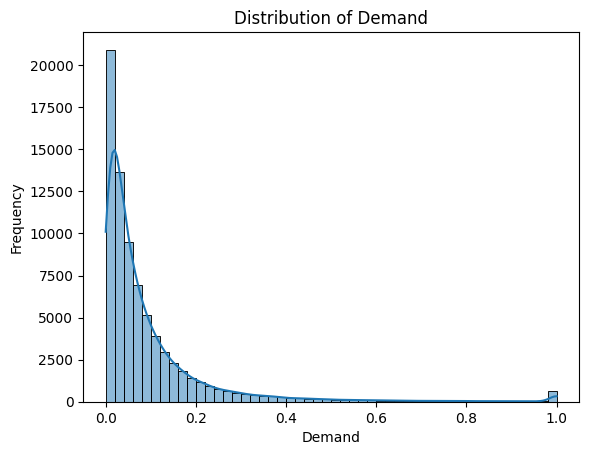

In [187]:
sns.histplot(train['demand'], bins=50, kde=True)
plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()


In [188]:
print("Unique days in train:", sorted(train['day'].unique()))
print("Unique timestamps (intervals) in train:", train['timestamp'].nunique())


Unique days in train: [np.int64(48), np.int64(49)]
Unique timestamps (intervals) in train: 96


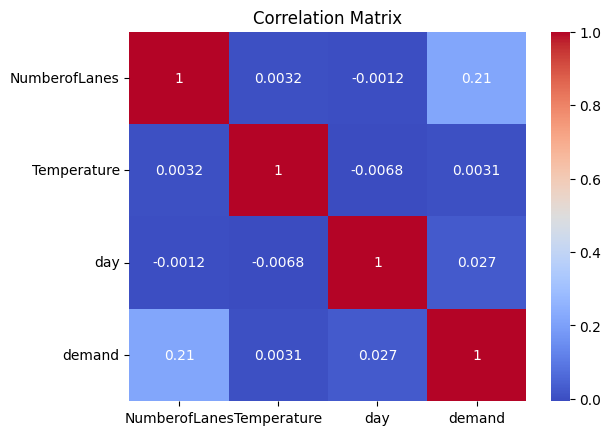

In [189]:
numeric_cols = ['NumberofLanes', 'Temperature', 'day']
corr = train[numeric_cols + ['demand']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [190]:
train = train.drop(columns=['Index'], errors='ignore')
test = test.drop(columns=['Index'], errors='ignore')

test['demand'] = np.nan
data = pd.concat([train, test], axis=0, ignore_index=True)

In [191]:
data['RoadType'] = data['RoadType'].fillna('Unknown')
data['Weather'] = data['Weather'].fillna('Unknown')

data['Temperature'] = data['Temperature'].fillna(data['Temperature'].median())



In [192]:
data['LargeVehicles'] = data['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0})
data['Landmarks'] = data['Landmarks'].map({'Yes': 1, 'No': 0})

label_enc_cols = ['geohash', 'RoadType', 'Weather']
for col in label_enc_cols:
    data[col] = data[col].astype(str)
    lbl = LabelEncoder()
    data[col] = lbl.fit_transform(data[col])


In [193]:
data['hour'] = data['timestamp'].str.split(':').str[0].astype(int)
data['minute'] = data['timestamp'].str.split(':').str[1].astype(int)
data['time_index'] = data['hour']*4 + data['minute']//15


In [194]:

data['day'] = data['day'].astype(int)


In [195]:
data = data.drop(columns=['timestamp'])


In [196]:
train_pre = data[data['demand'].notnull()].copy()
test_pre = data[data['demand'].isnull()].copy()
train_pre['demand'] = train_pre['demand'].astype(float)
test_pre = test_pre.drop(columns=['demand'])


In [197]:
features = ['geohash', 'day', 'hour', 'minute', 'time_index',
            'RoadType', 'NumberofLanes', 'LargeVehicles',
            'Landmarks', 'Temperature', 'Weather']
X = train_pre[features]
y = train_pre['demand']
X_test = test_pre[features]


In [198]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [199]:
cat_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    random_state=42,
    verbose=False
)

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))


CatBoostRegressor(depth=6, eval_metric='R2', iterations=200, learning_rate=0.1, loss_function='RMSE', random_state=42, verbose=False)

In [200]:
y_pred_val = cat_model.predict(X_val)
r2 = r2_score(y_val, y_pred_val)
print(f"CatBoost R² on validation set: {r2:.4f}")


CatBoost R² on validation set: 0.8336


In [201]:
importances = cat_model.get_feature_importance(prettified=True)
print("Feature Importances (CatBoost):")
print(importances.sort_values(by='Importances', ascending=False).head(10))


Feature Importances (CatBoost):
      Feature Id  Importances
0       RoadType    84.191257
1        geohash    12.427777
2     time_index     1.602010
3           hour     0.741249
4  NumberofLanes     0.534565
5            day     0.287938
6      Landmarks     0.093365
7    Temperature     0.058776
8  LargeVehicles     0.029396
9         minute     0.025294


In [202]:

def evaluate_model(model, X_tr, y_tr, X_va, y_va, name):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_va)
    score = r2_score(y_va, pred)
    print(f"{name} R² on validation: {score:.4f}")
    return score


models = {
    'CatBoost': CatBoostRegressor(iterations=200, learning_rate=0.1, depth=6, random_state=42, verbose=False),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
}

scores = {}
for name, model in models.items():
    scores[name] = evaluate_model(model, X_train, y_train, X_val, y_val, name)

best_model_name = max(scores, key=scores.get)
print(f"\nBest model: {best_model_name} (R² = {scores[best_model_name]:.4f})")


CatBoost R² on validation: 0.8336
XGBoost R² on validation: 0.8582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 11
[LightGBM] [Info] Start training from score 0.093784
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM R² on validation: 0.8537

Best model: XGBoost (R² = 0.8582)


In [203]:
from scipy.stats import uniform, randint

param_dist = {
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(3, 10),
    'l2_leaf_reg': uniform(1, 10),
    'iterations': randint(100, 500)
}

search_model = CatBoostRegressor(loss_function='RMSE', eval_metric='R2', random_state=42, verbose=False)
rand_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_dist,
    n_iter=10,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1
)
rand_search.fit(X_train, y_train)
print("Best params:", rand_search.best_params_)


Best params: {'depth': 6, 'iterations': 370, 'l2_leaf_reg': np.float64(5.56069984217036), 'learning_rate': np.float64(0.24555278841790407)}


In [204]:
best_params = rand_search.best_params_
best_cat = CatBoostRegressor(**best_params, loss_function='RMSE', eval_metric='R2', random_state=42, verbose=False)
best_cat.fit(X_train, y_train)
y_pred_val2 = best_cat.predict(X_val)
print(f"Optimized CatBoost R² on validation: {r2_score(y_val, y_pred_val2):.4f}")


Optimized CatBoost R² on validation: 0.8645


In [205]:
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = best_cat.fit(X_train, y_train)

    preds = model.predict(X_test)
    score = r2_score(y_test, preds)
    cv_scores.append(score)

print("Cross-validation R² scores:", np.round(cv_scores, 4))
print("Average R²:", np.round(np.mean(cv_scores), 4))

Cross-validation R² scores: [0.8638 0.8575 0.8641 0.8521 0.8599]
Average R²: 0.8595


In [206]:
best_cat.fit(X, y)

test_preds = best_cat.predict(X_test)

print("Test predictions sample:", test_preds[:5])


Test predictions sample: [0.0431415  0.06260681 0.03418832 0.03263003 0.01049496]


In [212]:
import pandas as pd
import numpy as np

final_sub = pd.read_csv('sample_submission.csv')

avg_prediction = np.mean(test_preds)
final_sub['demand'] = avg_prediction

final_sub.to_csv('submission.csv', index=False)
print("Success! File saved. Check the left panel to download.")

Success! File saved. Check the left panel to download.


In [208]:
imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': best_cat.get_feature_importance()
}).sort_values('Importance', ascending=False)
display(imp_df)


,Feature,Importance
5,RoadType,78.625579
0,geohash,16.263805
4,time_index,2.385197
2,hour,0.942592
6,NumberofLanes,0.742930
1,day,0.444341
9,Temperature,0.386063
7,LargeVehicles,0.075975
3,minute,0.071886
8,Landmarks,0.032874


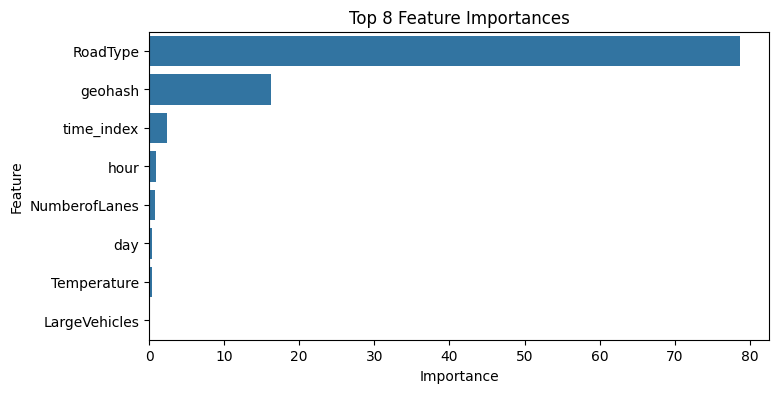

In [209]:
plt.figure(figsize=(8,4))
sns.barplot(x='Importance', y='Feature', data=imp_df.head(8))
plt.title("Top 8 Feature Importances")
plt.show()


In [213]:
import pandas as pd
import numpy as np

test_full = pd.read_csv('test.csv')

final_sub = pd.DataFrame()

if 'Index' in test_full.columns:
    final_sub['Index'] = test_full['Index']
else:
    final_sub['Index'] = test_full.index

avg_prediction = np.mean(test_preds)
final_sub['demand'] = avg_prediction

final_sub.to_csv('submission.csv', index=False)
print("New file generated successfully! Total rows:", len(final_sub))

New file generated successfully! Total rows: 41778
